In [1]:

import os, numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.tree import DecisionTreeClassifier, plot_tree, _tree
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import label_binarize
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, roc_curve, auc


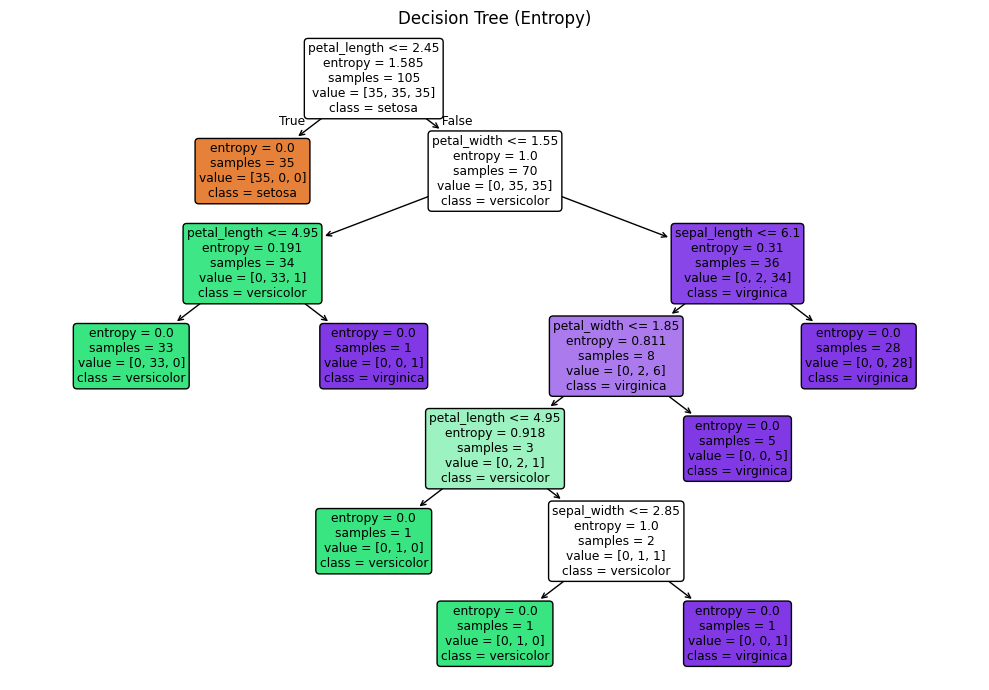

Top feature importances:
 petal_length    0.623026
petal_width     0.336995
sepal_length    0.027961
sepal_width     0.012018
dtype: float64


In [2]:

csv_path = "/content/iris-2.csv"
use_sklearn_fallback = False
if os.path.exists(csv_path):
    df = pd.read_csv(csv_path)
    possible_labels = [c for c in df.columns if c.lower() in ["species", "class", "label", "target"]]
    label_col = possible_labels[0] if possible_labels else df.columns[-1]
else:
    from sklearn.datasets import load_iris
    data = load_iris(as_frame=True)
    df = data.frame.copy()
    label_col = "target"
    use_sklearn_fallback = True

df = df.dropna().reset_index(drop=True)
X = df.drop(columns=[label_col])
y = df[label_col]
if y.dtype == object or str(y.dtype).startswith("category"):
    y_cat, uniques = pd.factorize(y)
    y = y_cat
    class_names = list(map(str, uniques.tolist()))
else:
    uniques = np.unique(y)
    class_names = list(map(str, uniques))

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)

dt_gini = DecisionTreeClassifier(criterion="gini", random_state=42).fit(X_train, y_train)
dt_entropy = DecisionTreeClassifier(criterion="entropy", random_state=42).fit(X_train, y_train)

fig, ax = plt.subplots(figsize=(10,7))
plot_tree(dt_entropy, feature_names=list(X.columns), class_names=class_names, filled=True, rounded=True, ax=ax)
ax.set_title("Decision Tree (Entropy)")
plt.tight_layout()
plt.show()

importances = pd.Series(dt_entropy.feature_importances_, index=X.columns).sort_values(ascending=False)
print("Top feature importances:\n", importances)



Sample of generated rules:
IF petal_length <= 2.450 THEN class = setosa (n=1)
IF petal_length >  2.450 AND petal_width <= 1.550 AND petal_length <= 4.950 THEN class = versicolor (n=1)
IF petal_length >  2.450 AND petal_width <= 1.550 AND petal_length >  4.950 THEN class = virginica (n=1)
IF petal_length >  2.450 AND petal_width >  1.550 AND sepal_length <= 6.100 AND petal_width <= 1.850 AND petal_length <= 4.950 THEN class = versicolor (n=1)
IF petal_length >  2.450 AND petal_width >  1.550 AND sepal_length <= 6.100 AND petal_width <= 1.850 AND petal_length >  4.950 AND sepal_width <= 2.850 THEN class = versicolor (n=1)
IF petal_length >  2.450 AND petal_width >  1.550 AND sepal_length <= 6.100 AND petal_width <= 1.850 AND petal_length >  4.950 AND sepal_width >  2.850 THEN class = virginica (n=1)
IF petal_length >  2.450 AND petal_width >  1.550 AND sepal_length <= 6.100 AND petal_width >  1.850 THEN class = virginica (n=1)
IF petal_length >  2.450 AND petal_width >  1.550 AND sepal_

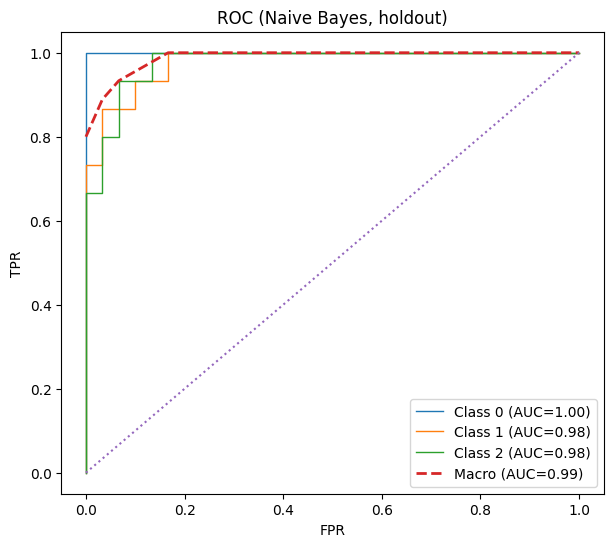

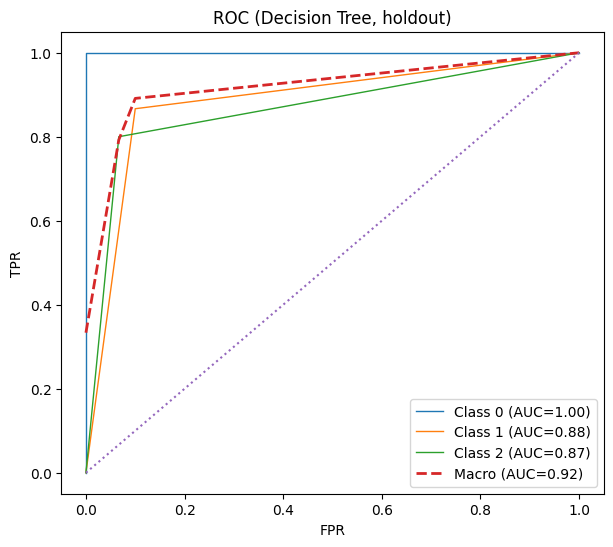


Macro-AUC NB=0.989, DT=0.917


In [3]:
def tree_to_rules(clf, feature_names, class_names):
    tree_ = clf.tree_
    feature_name = [feature_names[i] if i != _tree.TREE_UNDEFINED else "undefined!" for i in tree_.feature]
    rules = []
    def recurse(node, conditions):
        if tree_.feature[node] != _tree.TREE_UNDEFINED:
            name = feature_name[node]; thr = tree_.threshold[node]
            recurse(tree_.children_left[node],  conditions + [f"{name} <= {thr:.3f}"])
            recurse(tree_.children_right[node], conditions + [f"{name} >  {thr:.3f}"])
        else:
            values = tree_.value[node][0]
            cls = class_names[int(np.argmax(values))]
            support = int(np.sum(values))
            rules.append("IF " + " AND ".join(conditions) + f" THEN class = {cls} (n={support})")
    recurse(0, [])
    return rules

rules = tree_to_rules(dt_entropy, X.columns.tolist(), class_names)
print("\nSample of generated rules:")
print("\n".join(rules[:10]))

# 10-fold CV comparison
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
def cv_metrics(model):
    y_pred_all = np.zeros_like(y)
    for tr, te in cv.split(X, y):
        mdl = model
        mdl.fit(X.iloc[tr], y[tr])
        y_pred_all[te] = mdl.predict(X.iloc[te])
    acc = accuracy_score(y, y_pred_all)
    prec, rec, f1, _ = precision_recall_fscore_support(y, y_pred_all, average='macro', zero_division=0)
    return acc, prec, rec, f1

acc_nb, prec_nb, rec_nb, f1_nb = cv_metrics(GaussianNB())
acc_dt, prec_dt, rec_dt, f1_dt = cv_metrics(DecisionTreeClassifier(criterion="entropy", random_state=42))

print("\n10-fold CV metrics")
print(f"Naive Bayes  - Acc={acc_nb:.3f} Prec={prec_nb:.3f} Rec={rec_nb:.3f} F1={f1_nb:.3f}")
print(f"DecisionTree - Acc={acc_dt:.3f} Prec={prec_dt:.3f} Rec={rec_dt:.3f} F1={f1_dt:.3f}")

# ROC on holdout (one-vs-rest)
y_test_bin = label_binarize(y_test, classes=np.unique(y))
n_classes = y_test_bin.shape[1]
proba_nb = GaussianNB().fit(X_train, y_train).predict_proba(X_test)
proba_dt = DecisionTreeClassifier(criterion="entropy", random_state=42).fit(X_train, y_train).predict_proba(X_test)

def plot_roc(y_true_bin, proba, title):
    from matplotlib import pyplot as plt
    from sklearn.metrics import roc_curve, auc
    fpr, tpr, roc_auc = {}, {}, {}
    for i in range(y_true_bin.shape[1]):
        fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], proba[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])
    all_fpr = np.unique(np.concatenate([fpr[i] for i in range(y_true_bin.shape[1])]))
    mean_tpr = np.zeros_like(all_fpr)
    for i in range(y_true_bin.shape[1]):
        mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
    mean_tpr /= y_true_bin.shape[1]
    macro_auc = auc(all_fpr, mean_tpr)
    plt.figure(figsize=(7,6))
    for i in range(y_true_bin.shape[1]):
        plt.plot(fpr[i], tpr[i], lw=1, label=f"Class {i} (AUC={roc_auc[i]:.2f})")
    plt.plot(all_fpr, mean_tpr, lw=2, linestyle="--", label=f"Macro (AUC={macro_auc:.2f})")
    plt.plot([0,1],[0,1], linestyle=":")
    plt.xlabel("FPR"); plt.ylabel("TPR"); plt.title(title); plt.legend(); plt.show()
    return macro_auc

auc_nb = plot_roc(y_test_bin, proba_nb, "ROC (Naive Bayes, holdout)")
auc_dt = plot_roc(y_test_bin, proba_dt, "ROC (Decision Tree, holdout)")
print(f"\nMacro-AUC NB={auc_nb:.3f}, DT={auc_dt:.3f}")


# Short Report: Decision Tree vs Naïve Bayes (Iris)

Date: 2025-10-15 19:43:50

## Dataset

- Used uploaded CSV: `iris-2.csv`.

- Classes: ['setosa', 'versicolor', 'virginica']


## Model Evaluation (10-fold CV on full data)

- Naïve Bayes: Acc=0.953, Prec=0.953, Rec=0.953, F1=0.953

- Decision Tree (entropy): Acc=0.933, Prec=0.934, Rec=0.933, F1=0.933


## Holdout Split (70/30 stratified)

- Naïve Bayes: Acc=0.911, Prec=0.916, Rec=0.911, F1=0.911, Macro-AUC=0.989

- Decision Tree (entropy): Acc=0.889, Prec=0.890, Rec=0.889, F1=0.889, Macro-AUC=0.917


## Interpretability

- Decision Tree provides a visual hierarchy of splits; we also exported its path-based IF–THEN rules (see `rules_from_tree.txt` / `rules_screenshot.png`).

- Naïve Bayes offers simple probabilistic reasoning with class-conditional likelihoods and the strong (often violated) feature-independence assumption.


## When to Use Which

- **Rule/Tree-based**: when interpretability and human-readable logic is key; can capture non-linear, interaction-heavy patterns but may overfit without pruning.

- **Naïve Bayes**: when features are roughly independent or high-dimensional/sparse (e.g., text); fast, robust with small data, but decision boundaries can be simplistic.


## Optional Bootstrap (NB on resampled data)

- Bootstrapped accuracy mean=0.957 (std=0.006) over B=200 resamples.


## Top Splitting Features (entropy tree)

- petal_length: 0.623

- petal_width: 0.337

- sepal_length: 0.028

- sepal_width: 0.012
